# Projeto Banco de Filtros

### Número do Grupo : 5

## Etapas de Implementação
1. Definir frequências fs e orientações θk
2. Gerar filtros Gs,k(u, v) com a equação (1)
3. Aplicar sobre FFT da imagem: Is,k(u, v) = I(u, v) · Gs,k(u, v)
4. Realizar IFFT para obter is,k(x, y)

## Implementação

In [ ]:
# Importando as bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy import signal

In [ ]:
# Definindo as frequências
fmax = 0.25
a = np.sqrt(2)
S = 3
gama = 0.5

fs = np.array([])
for s in range (0, S):
  fs = np.append(fs, fmax * a**(-s))

print(f'Frequências: {fs}\n')

# Definindo as orientações
K = 6
theta = np.array([])

for k in range (1, K+1):
  theta = np.append(theta, k * np.pi / K)

print(f'Orientações em rad: {theta}')

Frequências: [0.25      0.1767767 0.125    ]

Orientações em rad: [0.52359878 1.04719755 1.57079633 2.0943951  2.61799388 3.14159265]


In [ ]:
# Definindo as larguras espectrais
sigma_u = fs/gama

delta = np.pi / K
sigma_v = fs / (gama * np.tan(delta))

print(f'Sigma u: {sigma_u}\nSigma v: {sigma_v}')

Sigma u: [0.5        0.35355339 0.25      ]
Sigma v: [0.8660254  0.61237244 0.4330127 ]


In [ ]:
# 2. Gerar filtros com as equações (1) a (5)

# Implementação do filtro

def gabor_freq(M,N,f,theta,sigma_u,sigma_v):
    u = np.linspace(-0.5, 0.5, M)
    v = np.linspace(-0.5, 0.5, N)
    U, V = np.meshgrid(u, v)

    d_u = U * np.cos(theta) + V * np.sin(theta)
    d_v = -U * np.sin(theta) + V * np.cos(theta)

    gab = np.exp(-np.pi**2 * (((d_u - f)**2/sigma_u**2) + d_v**2 / sigma_v**2))
    return gab

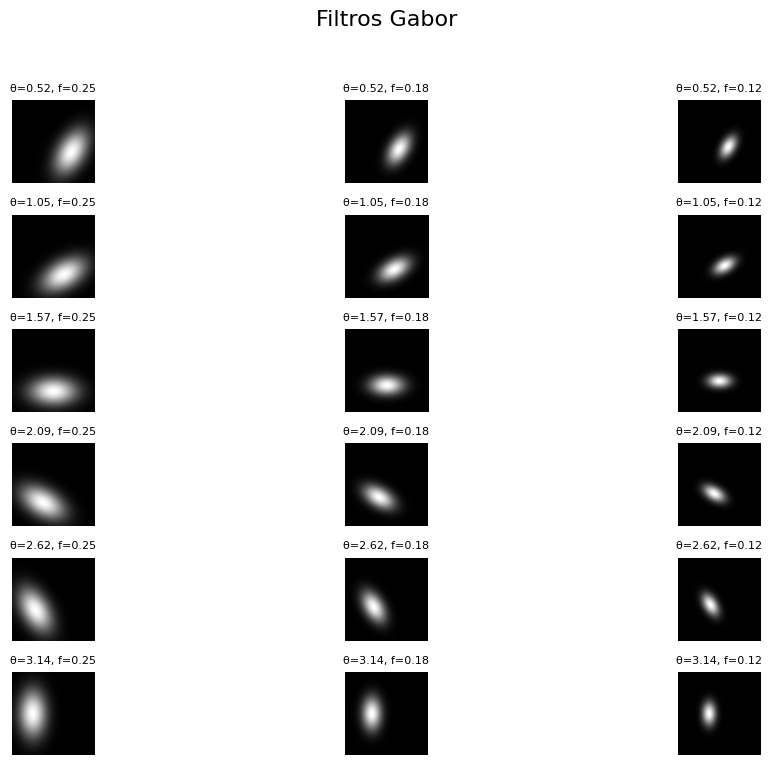

In [ ]:
# Qntd de pixels da imagem
M = 512
N = 512

filtros_gabor = []

# Criando cada filtro variando os parâmetros
for i in range(K):
  for j in range(S):
    filtro = gabor_freq(M, N, fs[j], theta[i], sigma_u[j], sigma_v[j])
    filtros_gabor.append(filtro)

fig, axes = plt.subplots(K, S, figsize=(12, 8))
fig.suptitle("Filtros Gabor", fontsize=16)

# Mostrando todos os filtros
for i in range(K):
    for j in range(S):
        ax = axes[i, j]
        ax.imshow(filtros_gabor[i * S + j], cmap="gray")
        ax.axis("off")
        ax.set_title(f'θ={theta[i]:.2f}, f={fs[j]:.2f}', fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

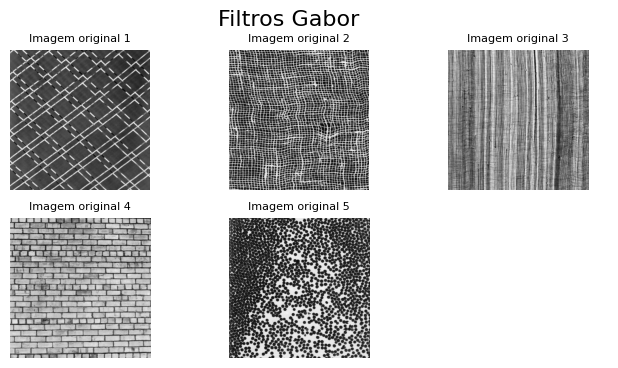

In [ ]:
# Imagem em que os filtros serão aplicados
num_images = 5

imageRGB = []
imageGRAY = []

for i in range (1, num_images + 1):
  imageRGB.append(cv2.imread(f'imagem{i}.jpg'))
  resized_image = cv2.resize(imageRGB[i-1], (M, N))
  imageGRAY.append(cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY))

fig, axes = plt.subplots(2, 3, figsize=(8, 4))
fig.suptitle("Filtros Gabor", fontsize=16)

image_index = 0
for i in range(axes.shape[0]):
    for j in range(axes.shape[1]):
        if image_index < len(imageGRAY):
            ax = axes[i, j]
            ax.imshow(imageGRAY[image_index], cmap="gray")
            ax.axis("off")
            ax.set_title(f'Imagem original {image_index + 1}', fontsize=8)
            image_index += 1
        else:
            axes[i, j].axis('off')

plt.show()

In [ ]:
# FFT da imagem para que seja possível fazer a convolução

todas_imagens_filtradas = []

for img_gray in imageGRAY:
  img_fft = np.fft.fft2(img_gray)
  img_fft_shift = np.fft.fftshift(img_fft)

  imagens_filtradas_por_imagem = []

  # Aplicando cada filtro de gabor separadamente
  for filtro in filtros_gabor:
    img_filtrada_freq = img_fft_shift * filtro
    img_filtrada_shift = np.fft.ifftshift(img_filtrada_freq)

    img_filtrada = np.fft.ifft2(img_filtrada_shift)
    img_filtrada = np.abs(img_filtrada)

    imagens_filtradas_por_imagem.append(img_filtrada)

  todas_imagens_filtradas.append(imagens_filtradas_por_imagem)

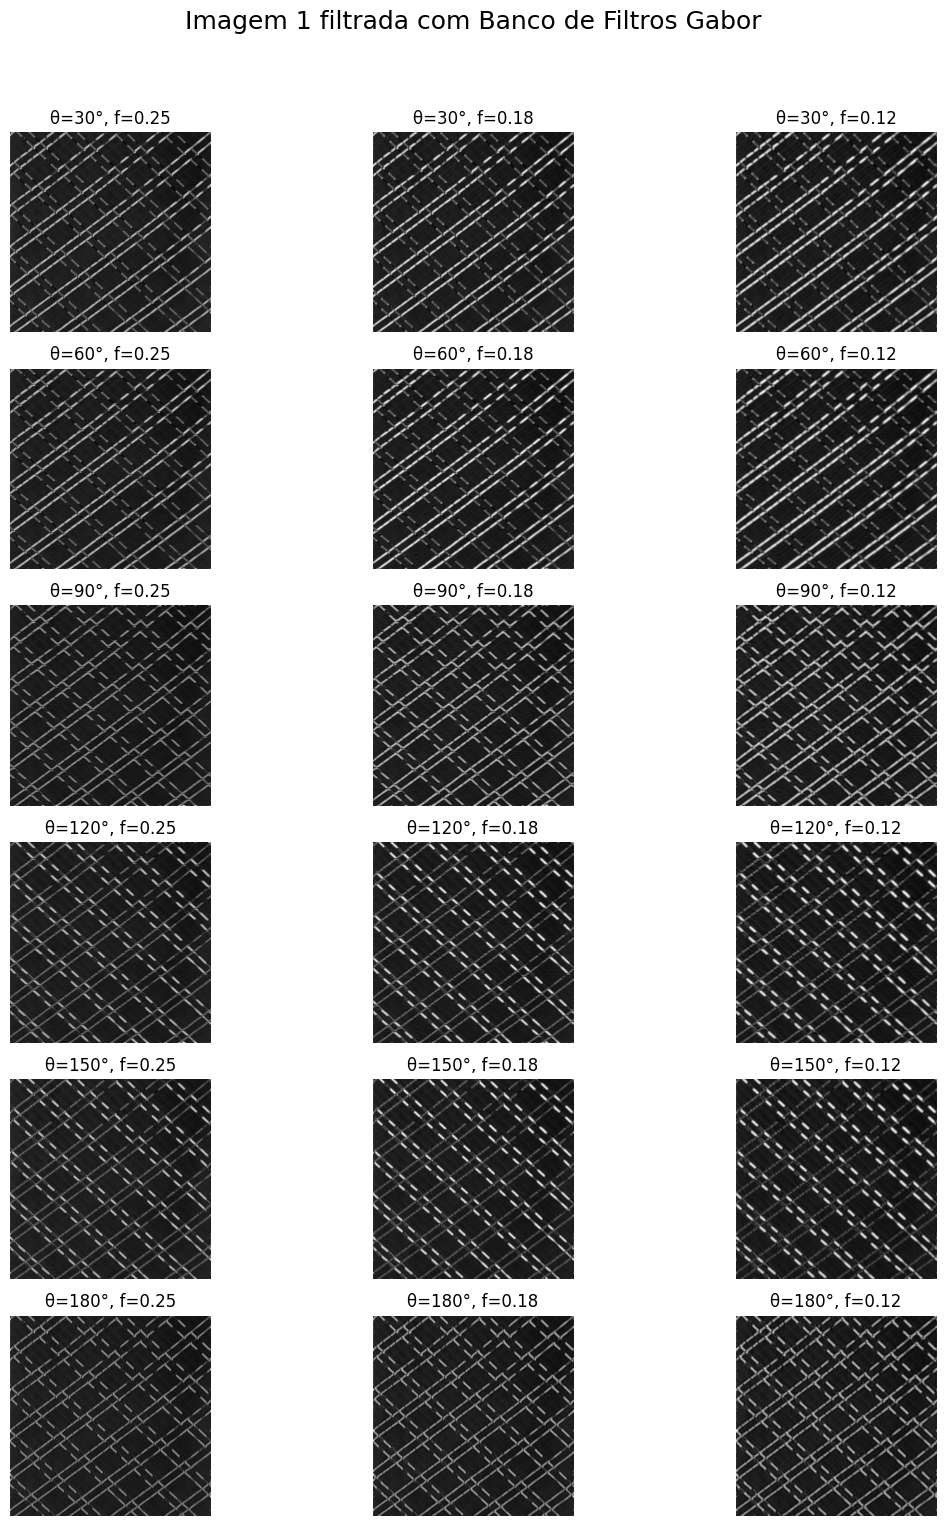

In [ ]:
# Plotando todas as imagens resultantes dos filtros da imagem
num = 1

fig, axes = plt.subplots(K, S, figsize=(12, 16))
fig.suptitle(f'Imagem {num} filtrada com Banco de Filtros Gabor', fontsize=18)

count = 0
for i in range(K):
    for j in range(S):
        ax = axes[i, j]
        ax.imshow(todas_imagens_filtradas[num-1][count], cmap="gray")
        ax.axis("off")
        ax.set_title(f"θ={theta[i]*180/np.pi:.0f}°, f={fs[j]:.2f}", fontsize=12)
        count += 1

plt.tight_layout(pad=1.0, rect=[0, 0.03, 1, 0.95])
plt.show()

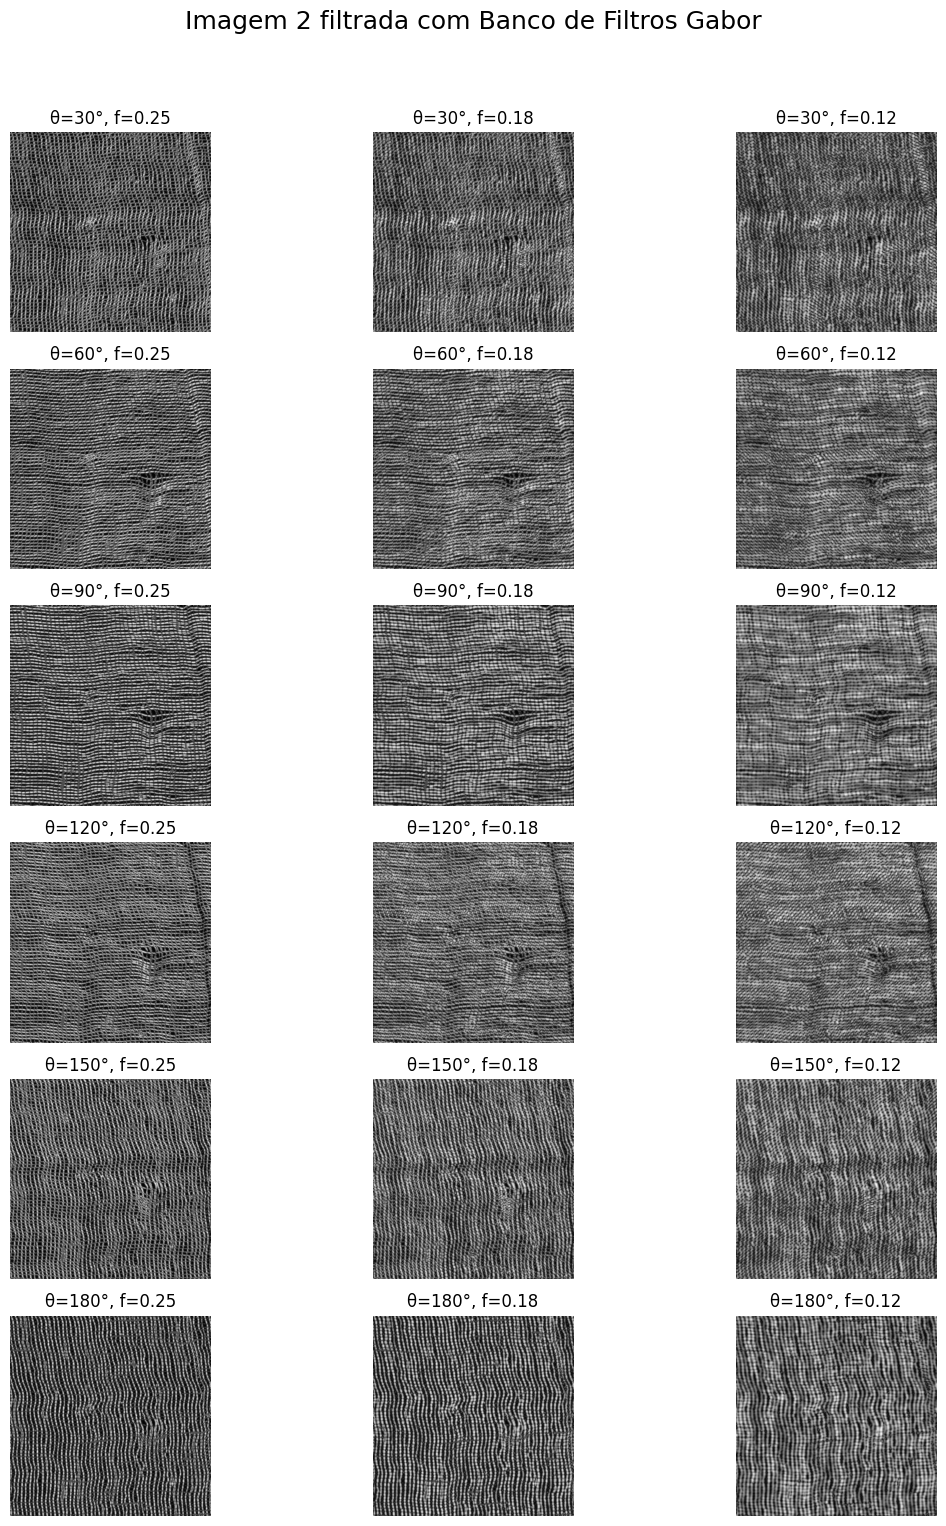

In [ ]:
# Plotando todas as imagens resultantes dos filtros da imagem
num = 2

fig, axes = plt.subplots(K, S, figsize=(12, 16))
fig.suptitle(f'Imagem {num} filtrada com Banco de Filtros Gabor', fontsize=18)

count = 0
for i in range(K):
    for j in range(S):
        ax = axes[i, j]
        ax.imshow(todas_imagens_filtradas[num-1][count], cmap="gray")
        ax.axis("off")
        ax.set_title(f"θ={theta[i]*180/np.pi:.0f}°, f={fs[j]:.2f}", fontsize=12)
        count += 1

plt.tight_layout(pad=1.0, rect=[0, 0.03, 1, 0.95])
plt.show()

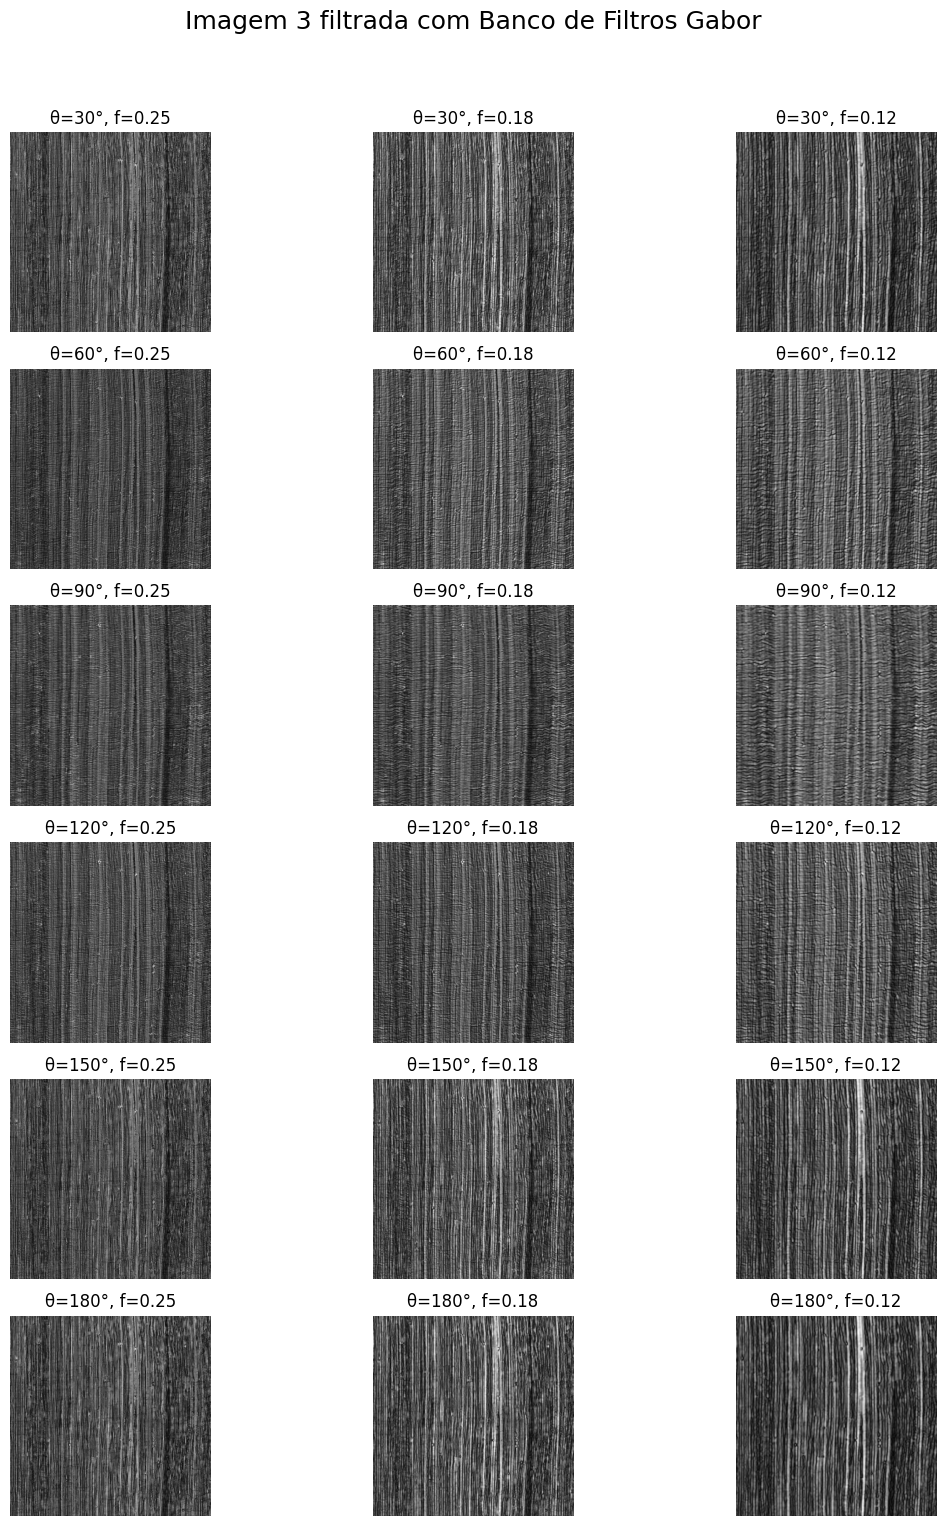

In [ ]:
# Plotando todas as imagens resultantes dos filtros da imagem
num = 3

fig, axes = plt.subplots(K, S, figsize=(12, 16))
fig.suptitle(f'Imagem {num} filtrada com Banco de Filtros Gabor', fontsize=18)

count = 0
for i in range(K):
    for j in range(S):
        ax = axes[i, j]
        ax.imshow(todas_imagens_filtradas[num-1][count], cmap="gray")
        ax.axis("off")
        ax.set_title(f"θ={theta[i]*180/np.pi:.0f}°, f={fs[j]:.2f}", fontsize=12)
        count += 1

plt.tight_layout(pad=1.0, rect=[0, 0.03, 1, 0.95])
plt.show()

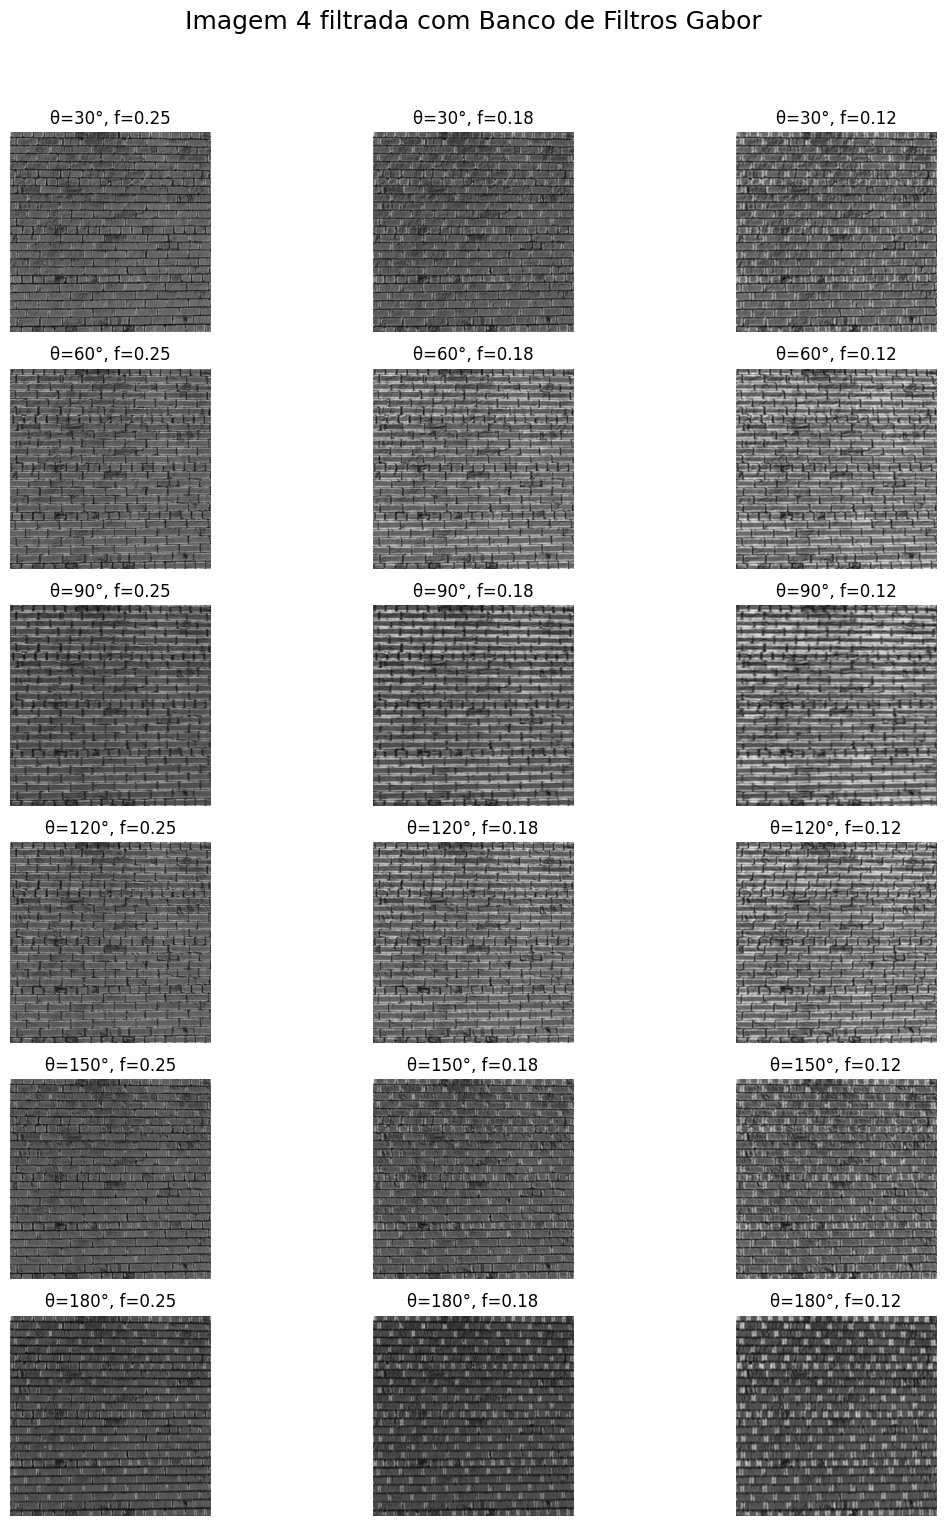

In [ ]:
# Plotando todas as imagens resultantes dos filtros da imagem
num = 4

fig, axes = plt.subplots(K, S, figsize=(12, 16))
fig.suptitle(f'Imagem {num} filtrada com Banco de Filtros Gabor', fontsize=18)

count = 0
for i in range(K):
    for j in range(S):
        ax = axes[i, j]
        ax.imshow(todas_imagens_filtradas[num-1][count], cmap="gray")
        ax.axis("off")
        ax.set_title(f"θ={theta[i]*180/np.pi:.0f}°, f={fs[j]:.2f}", fontsize=12)
        count += 1

plt.tight_layout(pad=1.0, rect=[0, 0.03, 1, 0.95])
plt.show()

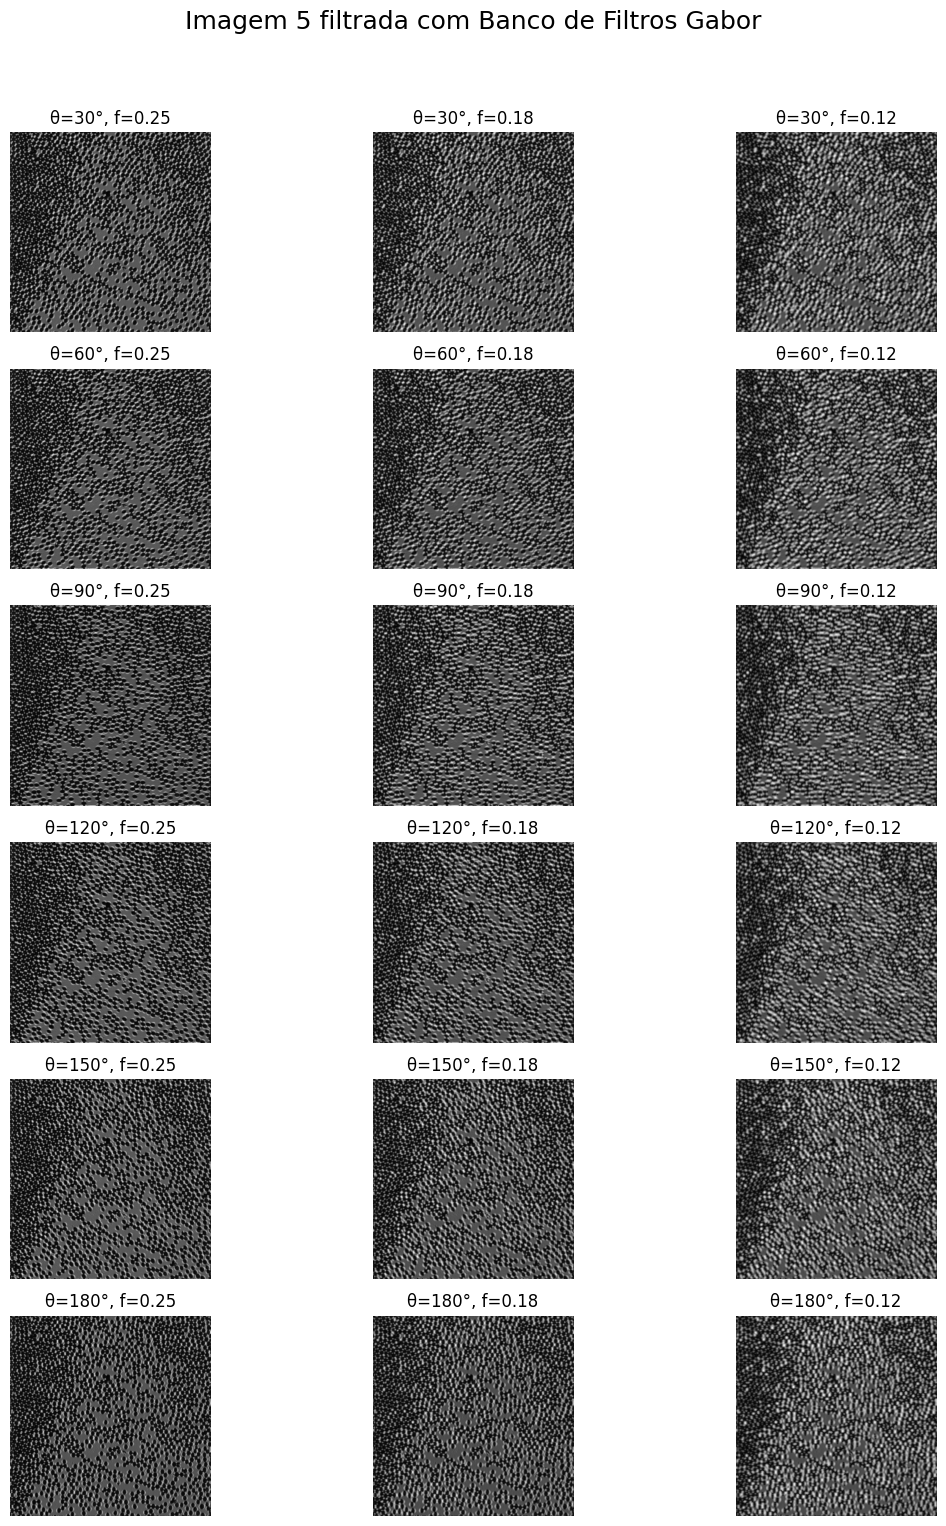

In [ ]:
# Plotando todas as imagens resultantes dos filtros da imagem
num = 5

fig, axes = plt.subplots(K, S, figsize=(12, 16))
fig.suptitle(f'Imagem {num} filtrada com Banco de Filtros Gabor', fontsize=18)

count = 0
for i in range(K):
    for j in range(S):
        ax = axes[i, j]
        ax.imshow(todas_imagens_filtradas[num-1][count], cmap="gray")
        ax.axis("off")
        ax.set_title(f"θ={theta[i]*180/np.pi:.0f}°, f={fs[j]:.2f}", fontsize=12)
        count += 1

plt.tight_layout(pad=1.0, rect=[0, 0.03, 1, 0.95])
plt.show()